# Ensemble Learning: Random Forest vs XGBoost

In this task, Random Forest and XGBoost are trained on the Telco Customer Churn dataset and compared with the Logistic Regression model from the previous task.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, classification_report

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [6]:
df["TotalCharges"].isnull().sum()

0

## Preparing the Data

Churn is the target variable. "Yes" represents customers who churned,
while "No" represents customers who stayed.

In [7]:
X = df.drop(columns=["Churn", "customerID"])

y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [8]:
y.value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 5634
Testing samples: 1409


In [10]:
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical:", numerical_features)
print("Categorical:", categorical_features)

Numerical: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [12]:
lr_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

lr_pipeline.fit(X_train, y_train)

lr_predictions = lr_pipeline.predict(X_test)

lr_accuracy = accuracy_score(
    y_test,
    lr_predictions
)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.8055358410220014


## Random Forest Classifier

Random Forest is an ensemble model that combines multiple decision trees.
Each tree learns from a different sample of the data, and their predictions
are combined to produce a more reliable final prediction.

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

rf_pipeline.fit(X_train, y_train)

rf_predictions = rf_pipeline.predict(X_test)

rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7828246983676366


In [14]:
print(classification_report(y_test, rf_predictions))

              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1035
           1       0.62      0.47      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.70      1409
weighted avg       0.77      0.78      0.77      1409



## XGBoost Classifier

XGBoost is a boosting-based ensemble algorithm. Instead of building trees
independently, it builds them sequentially, with each new tree focusing
on correcting errors made by previous trees.

In [15]:
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", XGBClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4,
            random_state=42,
            eval_metric="logloss"
        ))
    ]
)

xgb_pipeline.fit(X_train, y_train)

xgb_predictions = xgb_pipeline.predict(X_test)

xgb_accuracy = accuracy_score(
    y_test,
    xgb_predictions
)

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.8055358410220014


In [16]:
print(classification_report(y_test, xgb_predictions))

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.53      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



## Model Performance Comparison

The performance of Logistic Regression, Random Forest, and XGBoost is
compared using accuracy on the same test dataset.

In [17]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy,
        xgb_accuracy
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.805536
1,Random Forest,0.782825
2,XGBoost,0.805536


In [18]:
comparison["Accuracy (%)"] = (
    comparison["Accuracy"] * 100
).round(2)

comparison

,Model,Accuracy,Accuracy (%)
0,Logistic Regression,0.805536,80.55
1,Random Forest,0.782825,78.28
2,XGBoost,0.805536,80.55


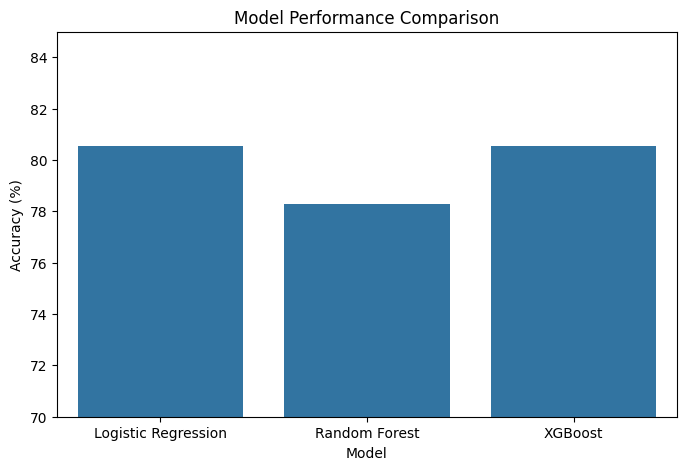

In [19]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy (%)"
)

plt.title("Model Performance Comparison")
plt.ylabel("Accuracy (%)")
plt.xlabel("Model")
plt.ylim(70, 85)

plt.show()

### Observation

Logistic Regression and XGBoost achieved the same accuracy of 80.55%, while
Random Forest achieved a lower accuracy of 78.28% on the test dataset.
Therefore, XGBoost did not improve overall accuracy over the Logistic
Regression baseline in this experiment, while Random Forest performed
slightly worse.

In [20]:
# Get feature names after preprocessing

feature_names = rf_pipeline.named_steps[
    "preprocessing"
].get_feature_names_out()

print("Number of features:", len(feature_names))

Number of features: 45


In [21]:
rf_importance = rf_pipeline.named_steps[
    "model"
].feature_importances_

rf_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_importance
})

rf_importance_df = rf_importance_df.sort_values(
    "Importance",
    ascending=False
)

rf_importance_df.head(10)

,Feature,Importance
3,num__TotalCharges,0.140630
1,num__tenure,0.132414
2,num__MonthlyCharges,0.122886
36,cat__Contract_Month-to-month,0.069253
18,cat__OnlineSecurity_No,0.039429
38,cat__Contract_Two year,0.035437
27,cat__TechSupport_No,0.033811
43,cat__PaymentMethod_Electronic check,0.028715
16,cat__InternetService_Fiber optic,0.028029
21,cat__OnlineBackup_No,0.017476


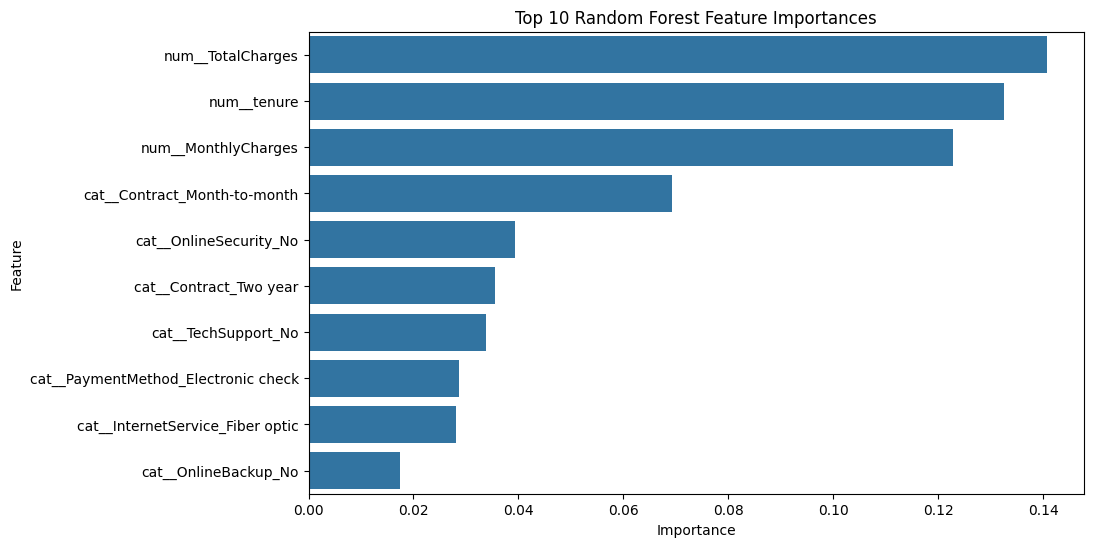

In [22]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=rf_importance_df.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [23]:
xgb_importance = xgb_pipeline.named_steps[
    "model"
].feature_importances_

xgb_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_importance
})

xgb_importance_df = xgb_importance_df.sort_values(
    "Importance",
    ascending=False
)

xgb_importance_df.head(10)

,Feature,Importance
36,cat__Contract_Month-to-month,0.510763
16,cat__InternetService_Fiber optic,0.144861
27,cat__TechSupport_No,0.037118
18,cat__OnlineSecurity_No,0.036082
15,cat__InternetService_DSL,0.024716
35,cat__StreamingMovies_Yes,0.022188
1,num__tenure,0.017539
37,cat__Contract_One year,0.016139
38,cat__Contract_Two year,0.015903
43,cat__PaymentMethod_Electronic check,0.013742


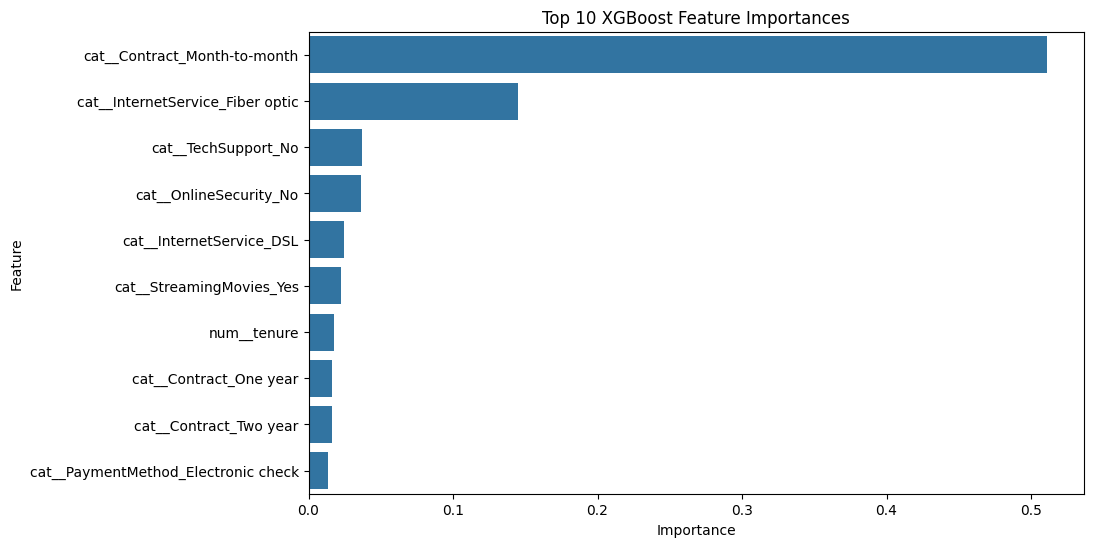

In [24]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=xgb_importance_df.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [25]:
rf_top = rf_importance_df.head(10)[
    ["Feature", "Importance"]
].rename(
    columns={"Importance": "RF Importance"}
)

xgb_top = xgb_importance_df.head(10)[
    ["Feature", "Importance"]
].rename(
    columns={"Importance": "XGB Importance"}
)

feature_comparison = pd.merge(
    rf_top,
    xgb_top,
    on="Feature",
    how="outer"
).fillna(0)

feature_comparison

,Feature,RF Importance,XGB Importance
0,cat__Contract_Month-to-month,0.069253,0.510763
1,cat__Contract_One year,0.000000,0.016139
2,cat__Contract_Two year,0.035437,0.015903
3,cat__InternetService_DSL,0.000000,0.024716
4,cat__InternetService_Fiber optic,0.028029,0.144861
5,cat__OnlineBackup_No,0.017476,0.000000
6,cat__OnlineSecurity_No,0.039429,0.036082
7,cat__PaymentMethod_Electronic check,0.028715,0.013742
8,cat__StreamingMovies_Yes,0.000000,0.022188
9,cat__TechSupport_No,0.033811,0.037118


## Random Forest vs XGBoost

Random Forest builds many decision trees independently and combines their
predictions to reduce variance and improve stability. XGBoost builds trees
sequentially, where each new tree focuses on correcting errors made by
previous trees. Random Forest mainly relies on averaging many diverse trees,
while XGBoost uses boosting to gradually improve the model. In this
experiment, XGBoost achieved the same accuracy as Logistic Regression,
while Random Forest performed slightly lower.

### Feature Importance Observation

Random Forest distributed feature importance across several features, with
TotalCharges, tenure, and MonthlyCharges among its most important features.

XGBoost assigned the highest importance to Contract_Month-to-month,
followed by InternetService_Fiber optic.

This shows that the two ensemble models can identify different patterns
as important even when they are trained on the same dataset.

In [26]:
final_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Metric": [
        "Accuracy",
        "Accuracy",
        "Accuracy"
    ],
    "Score": [
        round(lr_accuracy, 4),
        round(rf_accuracy, 4),
        round(xgb_accuracy, 4)
    ]
})

final_comparison

,Model,Metric,Score
0,Logistic Regression,Accuracy,0.8055
1,Random Forest,Accuracy,0.7828
2,XGBoost,Accuracy,0.8055


## Final Conclusion

In this experiment, Logistic Regression and XGBoost achieved the highest
accuracy of 80.55%, while Random Forest achieved 78.28%.

XGBoost matched the performance of the Logistic Regression baseline but did
not improve the overall accuracy in this experiment.

The feature importance results also showed that Random Forest and XGBoost
focused on different features, with XGBoost giving particularly high
importance to month-to-month contracts.

This experiment demonstrates that ensemble models do not always outperform
simpler models, and model performance depends on the dataset and configuration.